In [47]:
# =========================
# Importação de bibliotecas
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Configuração visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [48]:
# =========================
# Carregamento dos dados
# =========================

path = "../data/raw/"

t21 = pd.ExcelFile(path + "Tabela 2.1 (RendCaract_Geo).xls")
t27 = pd.ExcelFile(path + "Tabela 2.7 (RendInstru_caract_BR).xls")
t213 = pd.ExcelFile(path + "Tabela 2.13 (Indice_Gini_Geo).xls")
t215 = pd.ExcelFile(path + "Tabela 2.15 (Indice_Palma_Geo).xls")

anos = ['2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022','2023','2024']

In [49]:
estados = [
"Norte","Nordeste","Sudeste","Sul","Centro-Oeste","Brasil"
]

def classificar_nivel(df, coluna_local):

    nivel = []
    ultimo_estado = None

    for lugar in df[coluna_local]:

        if lugar in estados and lugar != ultimo_estado:
            nivel.append("estado")
            ultimo_estado = lugar

        elif lugar == ultimo_estado:
            nivel.append("capital")

        else:
            nivel.append("outro")

    df["nivel"] = nivel
    return df

In [50]:


lista_regioes = []

for ano in anos:
    t21 = pd.read_excel(
    path + "Tabela 2.1 (RendCaract_Geo).xls",
    sheet_name=ano,
    header=[1,2,3,4,5]
    )
    #achatando as colunas 
    t21.columns = [
        "_".join([str(i) for i in col if "Unnamed" not in str(i)])
        for col in t21.columns
    ]
    
       
    t21 = t21.rename(columns={
        t21.columns[0]: "regiao",
        t21.columns[1]: "renda_media",
        t21.columns[2]: "renda_mediana",
        t21.columns[3]: "renda_media_homem",
        t21.columns[4]: "renda_mediana_homem",
        t21.columns[5]: "renda_media_mulher",
        t21.columns[6]: "renda_mediana_mulher"
    })
    #chamando somente colunas validas
    t21 = t21[[
        "regiao",
        "renda_media",
        "renda_mediana",
        "renda_media_homem",
        "renda_mediana_homem",
        "renda_media_mulher",
        "renda_mediana_mulher"
    ]]

    # limpado até o limite dos dados
    t21 = t21.iloc[:60] 
    # resetando indice
    t21 = t21.reset_index(drop=True)

    # convertendo para números
    cols = [
        "renda_media",
        "renda_mediana",
        "renda_media_homem",
        "renda_mediana_homem",
        "renda_media_mulher",
        "renda_mediana_mulher"
    ]

    t21[cols] = t21[cols].apply(pd.to_numeric, errors="coerce")
    #retirar cidades
    t21 = classificar_nivel(t21, "regiao")
    t21 = t21[t21["nivel"] == "estado"]
    # adicionar coluna ano
    t21["ano"] = int(ano)

    lista_regioes.append(t21)

t21_final = pd.concat(lista_regioes, ignore_index=True)
t21_final = t21_final.drop(columns=["nivel"])

t21_final


,regiao,renda_media,renda_mediana,renda_media_homem,renda_mediana_homem,renda_media_mulher,renda_mediana_mulher,ano
0,Brasil,1697.131909,1006.875314,1720.477441,1018.682579,1674.772937,994.835874,2012
1,Norte,1143.744632,650.416436,1162.300634,654.786756,1125.341760,647.665703,2012
2,Nordeste,1038.470319,609.814098,1035.018933,610.682863,1041.733021,609.378646,2012
3,Sudeste,2062.590957,1255.733751,2100.780461,1270.938902,2026.099879,1240.069976,2012
4,Sul,2049.744621,1344.093869,2070.804111,1353.579545,2029.502408,1333.401847,2012
...,...,...,...,...,...,...,...,...
73,Norte,1388.970777,898.586015,1411.602233,918.551770,1366.498294,874.089392,2024
74,Nordeste,1312.436018,844.655461,1340.870143,864.010744,1285.972037,819.644574,2024
75,Sudeste,2376.814734,1500.540246,2454.180041,1539.146897,2303.395165,1467.293042,2024
76,Sul,2487.930279,1681.909215,2555.745740,1725.330834,2422.095997,1641.713250,2024


In [51]:


lista_regioes = []

for ano in anos:
    t213 = pd.read_excel(
    path + "Tabela 2.13 (Indice_Gini_Geo).xls",
    sheet_name=ano,
    header=[1,2,3,4,5,6]
    )
    #achatando as colunas 
    t213.columns = [
        "_".join([str(i) for i in col if "Unnamed" not in str(i)])
        for col in t213.columns
    ]
    
       
    t213 = t213.rename(columns={
    t213.columns[0]: "regiao",
    t213.columns[1]: "indice_gini"
    })

    # limpado até o limite dos dados
    t213 = t213.iloc[:60] 
    # resetando indice
    t213 = t213.reset_index(drop=True)

    #retirar cidades
    t213 = classificar_nivel(t213, "regiao")
    t213 = t213[t213["nivel"] == "estado"]
    # adicionar coluna ano
    t213["ano"] = int(ano)

    lista_regioes.append(t213)

t213_final = pd.concat(lista_regioes, ignore_index=True)
t213_final = t213_final.drop(columns=["nivel"])

t213_final


,regiao,indice_gini,ano
0,Brasil,0.539784,2012
1,Norte,0.543590,2012
2,Nordeste,0.545724,2012
3,Sudeste,0.516408,2012
4,Sul,0.477507,2012
...,...,...,...
73,Norte,0.487887,2024
74,Nordeste,0.499485,2024
75,Sudeste,0.489814,2024
76,Sul,0.456877,2024


In [52]:


lista_regioes = []

for ano in anos:
    t215 = pd.read_excel(
    path + "Tabela 2.15 (Indice_Palma_Geo).xls",
    sheet_name=ano,
    header=[1,2,3,4,5,6,7]
    )
    #achatando as colunas 
    t215.columns = [
        "_".join([str(i) for i in col if "Unnamed" not in str(i)])
        for col in t215.columns
    ]
    
     #renomeando as colunas

    t215 = t215.rename(columns={
        t215.columns[0]: "regiao",
        t215.columns[1]: "renda_40pobres",
        t215.columns[2]: "renda_50meio",
        t215.columns[3]: "renda_10ricos",
        t215.columns[4]: "indice_palma"     
    })

    # limpado até o limite dos dados
    t215 = t215.iloc[:60] 
    # resetando indice
    t215 = t215.reset_index(drop=True)

    #retirar cidades
    t215 = classificar_nivel(t215, "regiao")
    t215 = t215[t215["nivel"] == "estado"]
    # adicionar coluna ano
    t215["ano"] = int(ano)

    lista_regioes.append(t215)

t215_final = pd.concat(lista_regioes, ignore_index=True)
t215_final = t215_final.drop(columns=["nivel"])

t215_final


,regiao,renda_40pobres,renda_50meio,renda_10ricos,indice_palma,ano
0,Brasil,10.482041,46.692259,42.825699,4.085626,2012
1,Norte,10.441572,46.256466,43.301963,4.147073,2012
2,Nordeste,10.445490,45.607513,43.946998,4.207270,2012
3,Sudeste,11.844395,46.595502,41.560103,3.508841,2012
4,Sul,13.425297,48.709331,37.865372,2.820449,2012
...,...,...,...,...,...,...
73,Norte,12.799865,48.880445,38.319690,2.993757,2024
74,Nordeste,12.481121,47.411511,40.107368,3.213443,2024
75,Sudeste,12.917104,48.301104,38.781792,3.002360,2024
76,Sul,14.372222,49.623269,36.004509,2.505146,2024


In [53]:


lista_regioes = []
lista_ano = ['2016','2017','2018','2019','2022','2023','2024']
for ano in lista_ano:
    t414 = pd.read_excel(
    path + "Tabela 4.14 (TaxaAnalf_Geo).xls",
    sheet_name=ano,
    header=[1,2,3,4,5,6,7]
    )
    #achatando as colunas 
    t414.columns = [
        "_".join([str(i) for i in col if "Unnamed" not in str(i)])
        for col in t414.columns
    ]
    
     #renomeando as colunas

    t414 = t414.rename(columns={
        t414.columns[0]: "regiao",
        t414.columns[1]: "taxa_analfabetismo"

    })

    # limpado até o limite dos dados
    t414 = t414.iloc[:60] 
    # resetando indice
    t414 = t414.reset_index(drop=True)

    #retirar cidades
    t414 = classificar_nivel(t414, "regiao")
    t414 = t49[t49["nivel"] == "estado"]
    # adicionar coluna ano
    t414["ano"] = int(ano)

    lista_regioes.append(t414)

t414_final = pd.concat(lista_regioes, ignore_index=True)
t414_final = t414_final.drop(columns=["nivel"])

t414_final


,regiao,sem_instrucao,fundamental_incompleto,fundamental_completo,medio_incompleto,medio_completo,superior_incompleto,superior_completo,ano
0,Brasil,5.523888,26.451317,7.449616,4.868447,31.201625,4.126063,20.379043,2016
1,Norte,6.637180,28.190878,6.897982,5.212512,32.123874,4.359994,16.577580,2016
2,Nordeste,10.705831,30.884411,6.532058,5.242236,29.399732,3.144903,14.090829,2016
3,Sudeste,3.219146,23.461246,7.699959,4.490121,33.046634,4.208138,23.874755,2016
4,Sul,3.478339,27.778369,8.998382,4.616285,29.176219,4.948127,21.004278,2016
5,Centro-Oeste,3.999464,24.101220,6.652726,5.885905,29.908161,5.113585,24.338939,2016
6,Brasil,5.523888,26.451317,7.449616,4.868447,31.201625,4.126063,20.379043,2017
7,Norte,6.637180,28.190878,6.897982,5.212512,32.123874,4.359994,16.577580,2017
8,Nordeste,10.705831,30.884411,6.532058,5.242236,29.399732,3.144903,14.090829,2017
9,Sudeste,3.219146,23.461246,7.699959,4.490121,33.046634,4.208138,23.874755,2017


In [54]:


lista_regioes = []

lista_ano = ['2016','2017','2018','2019','2022','2023','2024']
for ano in lista_ano:
    t49 = pd.read_excel(
    path + "Tabela 4.9 (NivelInstru_Geo).xls",
    sheet_name=ano,
    header=[1,2,3,4,5]
    )
    #achatando as colunas 
    t49.columns = [
        "_".join([str(i) for i in col if "Unnamed" not in str(i)])
        for col in t49.columns
    ]
    
     #renomeando as colunas

    t49 = t49.rename(columns={
        t49.columns[0]: "regiao",
        t49.columns[1]: "sem_instrucao",
        t49.columns[2]: "fundamental_incompleto",
        t49.columns[3]: "fundamental_completo",
        t49.columns[4]: "medio_incompleto",
        t49.columns[5]: "medio_completo",
        t49.columns[6]: "superior_incompleto",
        t49.columns[7]: "superior_completo" 

    })

    # limpado até o limite dos dados
    t49 = t49.iloc[:60] 
    # resetando indice
    t49 = t49.reset_index(drop=True)

    #retirar cidades
    t49 = classificar_nivel(t49, "regiao")
    t49 = t49[t49["nivel"] == "estado"]

    # adicionar coluna ano
    t49["ano"] = int(ano)

    lista_regioes.append(t49)

t49_final = pd.concat(lista_regioes, ignore_index=True)
t49_final = t49_final.drop(columns=["nivel"])

t49_final


,regiao,sem_instrucao,fundamental_incompleto,fundamental_completo,medio_incompleto,medio_completo,superior_incompleto,superior_completo,ano
0,Brasil,7.317911,33.254104,9.244587,4.148983,27.109761,3.548826,15.375828,2016
1,Norte,9.364683,36.457087,7.863892,5.133073,26.829476,3.337090,11.014699,2016
2,Nordeste,14.183940,37.357708,7.114964,4.566714,24.169882,2.795455,9.811337,2016
3,Sudeste,4.204848,29.882278,10.146671,3.657886,29.743222,3.734938,18.630158,2016
4,Sul,4.096900,35.216723,10.992197,4.094284,25.147407,4.070553,16.381937,2016
5,Centro-Oeste,6.588857,32.127153,9.065849,4.792810,25.796060,4.205732,17.423539,2016
6,Brasil,6.756392,32.967675,8.581965,4.652390,27.526747,3.782976,15.731855,2017
7,Norte,8.360767,35.893124,7.362419,5.664977,27.359977,3.803043,11.555692,2017
8,Nordeste,13.595506,37.086381,6.758964,4.717871,24.838153,2.793554,10.209571,2017
9,Sudeste,3.601756,29.496435,9.359208,4.360795,30.412430,3.967253,18.802123,2017


In [55]:


lista_regioes = []

for ano in anos:
    t133 = pd.read_excel(
    path + "Tabela 1.33 (Horas_Geo).xls",
    sheet_name=ano,
    header=[1,2,3,4,5,6,7]
    )
    #achatando as colunas 
    t133.columns = [
        "_".join([str(i) for i in col if "Unnamed" not in str(i)])
        for col in t133.columns
    ]
    
     #renomeando as colunas

    t133 = t133.rename(columns={
        t133.columns[0]: "regiao",
        t133.columns[1]: "total_pessoas",
        t133.columns[2]: "hr_trabalho_ate_14_horas",
        t133.columns[3]: "hr_trabalho_de_15_30_horas",
        t133.columns[4]: "hr_trabalho_de_31_39_horas",
        t133.columns[5]: "hr_trabalho_de_40_44_horas",
        t133.columns[6]: "hr_trabalho_de_45_48_horas",
        t133.columns[7]: "hr_trabalho_acima_49_horas"            
    })

    # limpado até o limite dos dados
    t133 = t133.iloc[:60] 
    # resetando indice
    t133 = t133.reset_index(drop=True)

    #retirar cidades
    t133 = classificar_nivel(t133, "regiao")
    t133 = t133[t133["nivel"] == "estado"]
    # adicionar coluna ano
    t133["ano"] = int(ano)

    lista_regioes.append(t133)

t133_final = pd.concat(lista_regioes, ignore_index=True)
t133_final = t133_final.drop(columns=["nivel"])
t133_final = t133_final.drop(columns=["total_pessoas"])

t133_final


,regiao,hr_trabalho_ate_14_horas,hr_trabalho_de_15_30_horas,hr_trabalho_de_31_39_horas,hr_trabalho_de_40_44_horas,hr_trabalho_de_45_48_horas,hr_trabalho_acima_49_horas,ano
0,Norte,5.255301,20.717938,7.140118,31.933834,17.682062,17.270747,2012
1,Nordeste,6.551568,21.260025,6.909029,34.055001,16.110089,15.114288,2012
2,Sudeste,3.248370,12.563687,5.958108,41.592868,19.825048,16.811920,2012
3,Sul,3.789816,12.935994,5.328006,44.984241,15.311195,17.650748,2012
4,Centro-Oeste,3.261212,14.037456,6.506731,41.214897,18.821725,16.157979,2012
...,...,...,...,...,...,...,...,...
60,Norte,3.775487,23.503690,4.791476,48.738758,9.887261,9.303327,2024
61,Nordeste,5.095755,22.304088,4.260530,49.577031,9.004699,9.757898,2024
62,Sudeste,3.316705,12.835336,4.066872,56.546910,9.869800,13.364376,2024
63,Sul,2.634999,12.377511,3.275797,61.431605,7.627915,12.652173,2024


In [56]:
desigualdade_regioes = t21_final.merge(t213_final, on=["regiao","ano"])
desigualdade_regioes = desigualdade_regioes.merge(t215_final, on=["regiao","ano"])
desigualdade_regioes = desigualdade_regioes.merge(t414_final, on=["regiao","ano"])
desigualdade_regioes = desigualdade_regioes.merge(t49_final, on=["regiao","ano"])
desigualdade_regioes = desigualdade_regioes.merge(t133_final, on=["regiao","ano"])
desigualdade_regioes

,regiao,renda_media,renda_mediana,renda_media_homem,renda_mediana_homem,renda_media_mulher,renda_mediana_mulher,ano,indice_gini,renda_40pobres,...,medio_incompleto_y,medio_completo_y,superior_incompleto_y,superior_completo_y,hr_trabalho_ate_14_horas,hr_trabalho_de_15_30_horas,hr_trabalho_de_31_39_horas,hr_trabalho_de_40_44_horas,hr_trabalho_de_45_48_horas,hr_trabalho_acima_49_horas
0,Norte,1053.226887,631.575239,1060.256697,635.698209,1046.153614,629.306141,2016,0.523487,10.983254,...,5.133073,26.829476,3.337090,11.014699,3.937909,23.360393,5.681682,46.382203,10.908153,9.729661
1,Nordeste,1076.955816,645.291355,1079.057444,646.223426,1074.967721,644.078510,2016,0.543498,10.361879,...,4.566714,24.169882,2.795455,9.811337,5.191933,22.909509,4.682165,46.266652,11.099255,9.850486
2,Sudeste,2117.428470,1285.123963,2171.078333,1302.095781,2066.536820,1271.425923,2016,0.523127,11.498227,...,3.657886,29.743222,3.734938,18.630158,3.240367,12.855190,4.318071,54.835735,12.861705,11.888932
3,Sul,2043.445320,1387.358695,2068.733507,1407.239708,2019.070463,1367.303264,2016,0.463014,13.872376,...,4.094284,25.147407,4.070553,16.381937,3.000043,12.956582,3.635237,58.782360,8.284040,13.341738
4,Centro-Oeste,1930.368170,1194.182093,1977.648279,1218.599142,1884.524334,1175.263436,2016,0.513893,11.999379,...,4.792810,25.796060,4.205732,17.423539,2.863530,14.464255,3.797183,58.396968,10.747128,9.730936
5,Norte,1092.095932,659.228801,1122.830138,670.434377,1061.316384,656.416125,2017,0.529907,10.844279,...,5.664977,27.359977,3.803043,11.555692,4.962653,23.050026,5.782562,45.287443,10.064668,10.852648
6,Nordeste,1094.482798,660.016138,1116.379637,658.378752,1073.723652,661.188277,2017,0.555535,9.777674,...,4.717871,24.838153,2.793554,10.209571,6.291715,23.364528,4.649564,45.719365,10.060382,9.914444
7,Sudeste,2070.779889,1289.411075,2112.712327,1306.830134,2031.085126,1272.781142,2017,0.520544,11.539689,...,4.360795,30.412430,3.967253,18.802123,3.615530,13.280616,4.340140,54.360455,11.615372,12.787888
8,Sul,2111.971944,1425.455291,2122.621415,1436.832117,2101.658457,1419.340979,2017,0.465765,13.780015,...,4.602353,24.910688,4.570941,16.702058,3.298841,13.745791,3.396654,58.459566,7.670408,13.428741
9,Centro-Oeste,2015.206008,1231.661251,2042.135292,1260.317217,1989.273335,1205.255979,2017,0.521086,11.722045,...,5.257980,25.222284,4.510352,18.796166,3.219524,15.257804,3.823161,55.297161,10.862899,11.539451


In [57]:


lista_regioes = []

for ano in anos:



        t27 = pd.read_excel(
            path + "Tabela 2.7 (RendInstru_caract_BR).xls",
            sheet_name=ano,
            header=[1,2,3,4,5]
        )
        #Achatando as colunas 
        t27.columns = [
            "_".join([str(i) for i in col if "Unnamed" not in str(i)])
            for col in t27.columns
        ]
        #renomeando as colunas
        t27 = t27.rename(columns={
            t27.columns[0]: "escolaridade",
            t27.columns[1]: "renda_",
            t27.columns[2]: "renda_homem",
            t27.columns[3]: "renda_mulher"
        })

        #achamando somente colunas validas
        t27 = t27[[
        "escolaridade",
        "renda_",
        "renda_homem",
        "renda_mulher"
        ]]

        #Separando os datasets
        t27_media = t27.iloc[0:5].copy()
        t27_media = t27_media.rename(columns={
            t27_media.columns[0]: "escolaridade",
            t27_media.columns[1]: "renda_media",
            t27_media.columns[2]: "renda_media_homem",
            t27_media.columns[3]: "renda_media_mulher"
        })
        t27_mediana = t27.iloc[6:11].copy()
        t27_mediana = t27_mediana.rename(columns={
            t27_mediana.columns[0]: "escolaridade",
            t27_mediana.columns[1]: "renda_mediana",
            t27_mediana.columns[2]: "renda_mediana_homem",
            t27_mediana.columns[3]: "renda_mediana_mulher"
        })

        #unir as tabelas
        t27 = pd.merge(
            t27_media,
            t27_mediana,
            on="escolaridade",
            how="left"
        )

        # adicionar coluna ano
        t27["ano"] = int(ano)

        lista_regioes.append(t27)

t27_final = pd.concat(lista_regioes, ignore_index=True)
t27_final


,escolaridade,renda_media,renda_media_homem,renda_media_mulher,renda_mediana,renda_mediana_homem,renda_mediana_mulher,ano
0,Total,1697.131909,1720.477441,1674.772937,1006.875314,1018.682579,994.835874,2012
1,Sem instrução ou fundamental incompleto,1117.447518,1112.571801,1122.368262,839.577424,840.279000,838.838220,2012
2,Ensino fundamental completo ou médio incompleto,1365.710582,1439.004115,1293.200283,972.014420,1041.860863,901.171108,2012
3,Ensino médio completo ou superior incompleto,2023.579365,2161.832642,1901.438032,1412.102831,1525.736710,1311.296217,2012
4,Ensino superior completo,5469.392172,6090.339458,5023.085763,3536.391587,3986.448495,3280.499500,2012
...,...,...,...,...,...,...,...,...
60,Total,2017.273643,2076.932539,1960.483028,1327.603920,1357.212439,1282.574571,2024
61,Sem instrução ou fundamental incompleto,1345.987550,1361.883514,1329.518796,1136.847470,1140.290062,1132.024550,2024
62,Ensino fundamental completo ou médio incompleto,1473.492413,1557.585824,1385.207794,1092.166122,1179.671059,1006.067494,2024
63,Ensino médio completo ou superior incompleto,1921.076193,2084.712430,1771.147846,1423.266422,1540.735557,1332.845671,2024


In [58]:
t27_final.to_excel("escolaridade_renda_brasil.xlsx", index=False)
desigualdade_regioes.to_excel("desigualdade_macro_regioes_2012_2024.xlsx", index=False)


<Axes: >

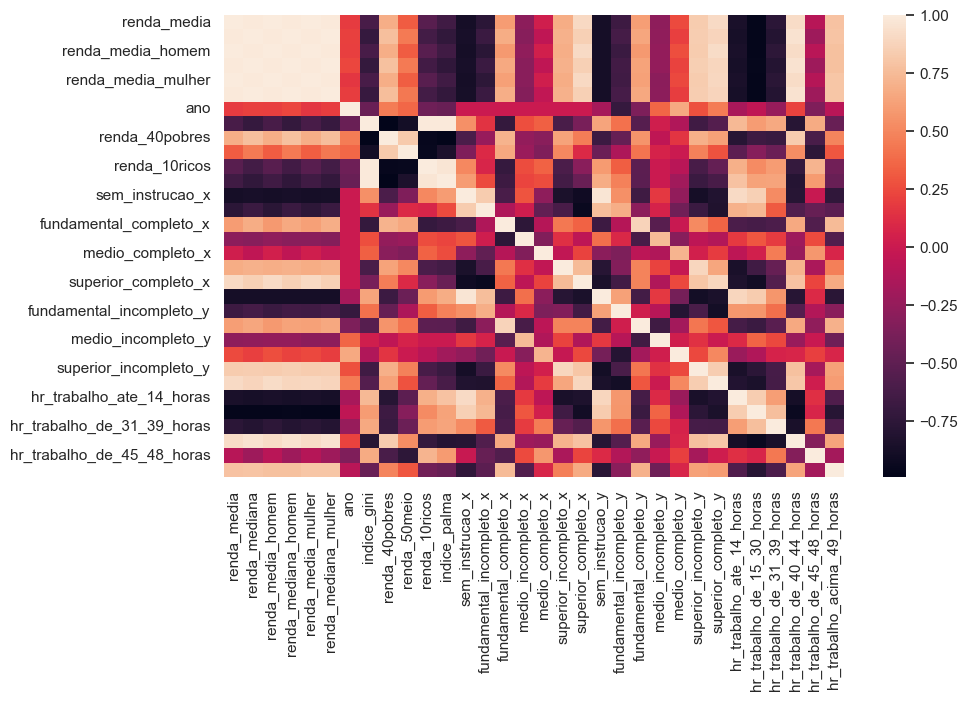

In [61]:
corr = desigualdade_regioes.corr(numeric_only=True)
sns.heatmap(corr)
